<a href="https://colab.research.google.com/github/ruhmmachaudhary-rgb/AI-ML-Fellowship-GDGOC-Atk/blob/main/week5/linear-regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MSE (From Scratch): 0.654


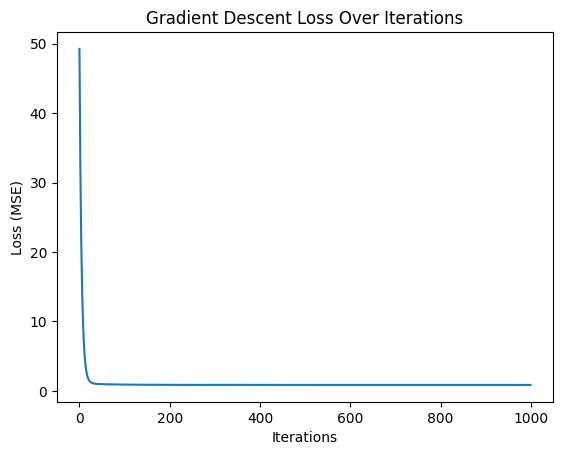

MSE (Scikit-Learn): 0.654


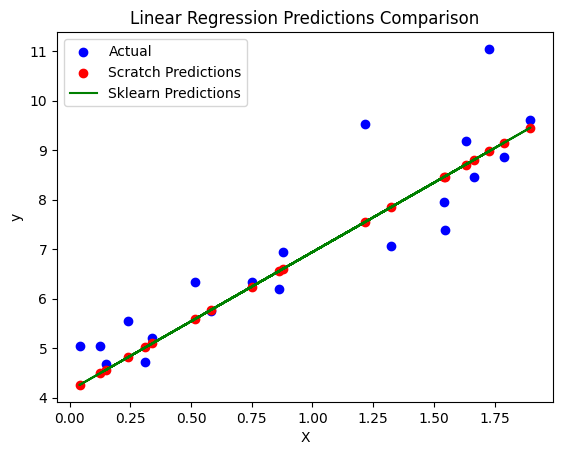

In [1]:

# Week 5: Linear Regression & Gradient Descent


# 1️ Introduction to ML

"""
Machine Learning (ML) is a subset of Artificial Intelligence where models learn patterns
from data to make predictions or decisions.

Types of ML:
1. Supervised Learning: Predict output from input (Linear Regression, Classification)
2. Unsupervised Learning: Find patterns in data (Clustering, PCA)
3. Reinforcement Learning: Learn via trial and error (Q-Learning, Game AI)

Linear Regression is a supervised ML algorithm used to predict continuous values.
"""

# 2️ Import Libraries

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# 3️ Generate Sample Data
np.random.seed(42)
X = 2 * np.random.rand(100, 1)   # 100 samples, feature values between 0 and 2
y = 4 + 3 * X + np.random.randn(100, 1)  # y = 4 + 3X + noise

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4️ Linear Regression From Scratch

class LinearRegressionScratch:
    def __init__(self, lr=0.01, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros((n_features, 1))
        self.b = 0

        for i in range(self.n_iters):
            y_pred = X @ self.w + self.b
            dw = (1/n_samples) * X.T @ (y_pred - y)
            db = (1/n_samples) * np.sum(y_pred - y)

            # Update weights
            self.w -= self.lr * dw
            self.b -= self.lr * db

            # Compute loss
            loss = (1/n_samples) * np.sum((y - y_pred) ** 2)
            self.loss_history.append(loss)

    def predict(self, X):
        return X @ self.w + self.b

# Train the model
model_scratch = LinearRegressionScratch(lr=0.05, n_iters=1000)
model_scratch.fit(X_train, y_train)
y_pred_scratch = model_scratch.predict(X_test)

# Compute MSE
mse_scratch = mean_squared_error(y_test, y_pred_scratch)
print(f"MSE (From Scratch): {mse_scratch:.3f}")

# Plot Loss over Iterations
plt.plot(model_scratch.loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.title("Gradient Descent Loss Over Iterations")
plt.show()

# 5️ Linear Regression Using Scikit-Learn

sk_model = LinearRegression()
sk_model.fit(X_train, y_train)
y_pred_sk = sk_model.predict(X_test)

mse_sk = mean_squared_error(y_test, y_pred_sk)
print(f"MSE (Scikit-Learn): {mse_sk:.3f}")

# Plot predictions
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.scatter(X_test, y_pred_scratch, color='red', label='Scratch Predictions')
plt.plot(X_test, y_pred_sk, color='green', label='Sklearn Predictions')
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression Predictions Comparison")
plt.legend()
plt.show()